<a href="https://colab.research.google.com/github/Balachandar-Ganesan/DeepLearning/blob/main/007_102_HowTensorWorks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf

# In TF 2.x, Eager Execution is on by default.
# No need for ops.reset_default_graph() or tf.Session()

# 1. Prepare data directly (Replaces tf.placeholder)
rand_array = np.random.rand(4, 4).astype(np.float32)

# 2. Define operations (Replaces tf.identity(x))
# Tensors are evaluated immediately
y = tf.identity(rand_array)

# 3. Logging for TensorBoard (Replaces tf.summary.FileWriter)
writer = tf.summary.create_file_writer("/tmp/variable_logs")

with writer.as_default():
    # In TF2, you log data directly during execution
    # Example: logging the result as a generic summary or specific type
    tf.summary.histogram("y_identity", y, step=0)

# 4. Direct Printing (Replaces sess.run)
print(y.numpy())


[[0.44345394 0.5780921  0.8817908  0.39601576]
 [0.68861836 0.686158   0.01238098 0.16200787]
 [0.0017313  0.32152748 0.6783811  0.5803845 ]
 [0.23926415 0.55909604 0.4196539  0.3335551 ]]


In [2]:
import numpy as np
import tensorflow as tf

# No sess = tf.Session() needed

# 1. Identity matrix
# tf.diag is now tf.linalg.tensor_diag
identity_matrix = tf.linalg.tensor_diag([1.0, 1.0, 1.0])
print("Identity:\n", identity_matrix.numpy())

# 2. 2x3 random normal matrix
A = tf.random.truncated_normal([2, 3])
print("\nA:\n", A.numpy())

# 3. 2x3 constant matrix
B = tf.fill([2, 3], 5.0)
print("\nB:\n", B.numpy())

# 4. 3x2 random uniform matrix
C = tf.random.uniform([3, 2])
print("\nC:\n", C.numpy())

# 5. Create matrix from np array
D = tf.convert_to_tensor(np.array([[1., 2., 3.], [-3., -7., -1.], [0., 5., -2.]]), dtype=tf.float32)
print("\nD:\n", D.numpy())

# 6. Matrix addition/subtraction
print("\nA + B:\n", (A + B).numpy())
print("\nB - B:\n", (B - B).numpy())

# 7. Matrix Multiplication
print("\nB * Identity:\n", tf.matmul(B, identity_matrix).numpy())

# 8. Matrix Transpose
print("\nC Transpose:\n", tf.transpose(C).numpy())

# 9. Matrix Determinant
print("\nDet(D):\n", tf.linalg.det(D).numpy())

# 10. Matrix Inverse
print("\nInv(D):\n", tf.linalg.inv(D).numpy())

# 11. Cholesky Decomposition
print("\nCholesky:\n", tf.linalg.cholesky(identity_matrix).numpy())

# 12. Eigenvalues and Eigenvectors
# Returns (eigenvalues, eigenvectors)
eigenvalues, eigenvectors = tf.linalg.eigh(D)
print("\nEigenvalues:\n", eigenvalues.numpy())


Identity:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

A:
 [[ 1.0438666  -1.8044564   0.06441021]
 [ 0.66387635 -0.5502506  -0.03895378]]

B:
 [[5. 5. 5.]
 [5. 5. 5.]]

C:
 [[0.5877112  0.02116752]
 [0.5796211  0.7452774 ]
 [0.5508566  0.47868764]]

D:
 [[ 1.  2.  3.]
 [-3. -7. -1.]
 [ 0.  5. -2.]]

A + B:
 [[6.0438666 3.1955438 5.06441  ]
 [5.6638765 4.4497495 4.961046 ]]

B - B:
 [[0. 0. 0.]
 [0. 0. 0.]]

B * Identity:
 [[5. 5. 5.]
 [5. 5. 5.]]

C Transpose:
 [[0.5877112  0.5796211  0.5508566 ]
 [0.02116752 0.7452774  0.47868764]]

Det(D):
 -38.0

Inv(D):
 [[-0.50000006 -0.5        -0.50000006]
 [ 0.15789475  0.05263158  0.21052633]
 [ 0.39473686  0.13157895  0.0263158 ]]

Cholesky:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Eigenvalues:
 [-10.659076    -0.22750695   2.886583  ]


In [1]:
import tensorflow as tf
import numpy as np

# 1. Division Operations
# tf.div is deprecated; use / for truediv and // for floordiv
print(tf.math.divide(3, 4).numpy())      # Results in 0.75
print(tf.cast(3 // 4, tf.int32).numpy()) # Integer floor division (0)
print(tf.math.floordiv(3.0, 4.0).numpy()) # Float floor division (0.0)

# 2. Mod function
print(tf.math.mod(22.0, 5.0).numpy())

# 3. Cross Product
print(tf.linalg.cross([1., 0., 0.], [0., 1., 0.]).numpy())

# 4. Trig functions
print(tf.math.sin(3.1416).numpy())
print(tf.math.cos(3.1416).numpy())
print(tf.math.tan(3.1416/4.).numpy())

# 5. Custom operation
def custom_polynomial(x_val):
    # In TF2, you can use standard math operators (+, -, *)
    # instead of tf.subtract or tf.add
    return 3 * tf.square(x_val) - x_val + 10

# Direct execution
print(f"Polynomial at 11: {custom_polynomial(11).numpy()}")

# 6. List comprehension comparison
test_nums = range(15)
expected_output = [3*x*x-x+10 for x in test_nums]
print(f"Expected: {expected_output}")

# TensorFlow custom function output (running eagerly)
tf_output = [custom_polynomial(num).numpy() for num in test_nums]
print(f"TF Output: {tf_output}")


0.75
0
0.0
2.0
[0. 0. 1.]
-7.2399803e-06
-1.0
1.0000036
Polynomial at 11: 362
Expected: [10, 12, 20, 34, 54, 80, 112, 150, 194, 244, 300, 362, 430, 504, 584]
TF Output: [np.int32(10), np.int32(12), np.int32(20), np.int32(34), np.int32(54), np.int32(80), np.int32(112), np.int32(150), np.int32(194), np.int32(244), np.int32(300), np.int32(362), np.int32(430), np.int32(504), np.int32(584)]


[ 0.  3. 10.]
[0. 3. 6.]
[0.26894143 0.5        0.7310586 ]
[-0.7615942  0.         0.7615942]
[-0.5  0.   0.5]
[0.3132617 0.6931472 1.3132616]
[-0.63212055  0.          1.        ]


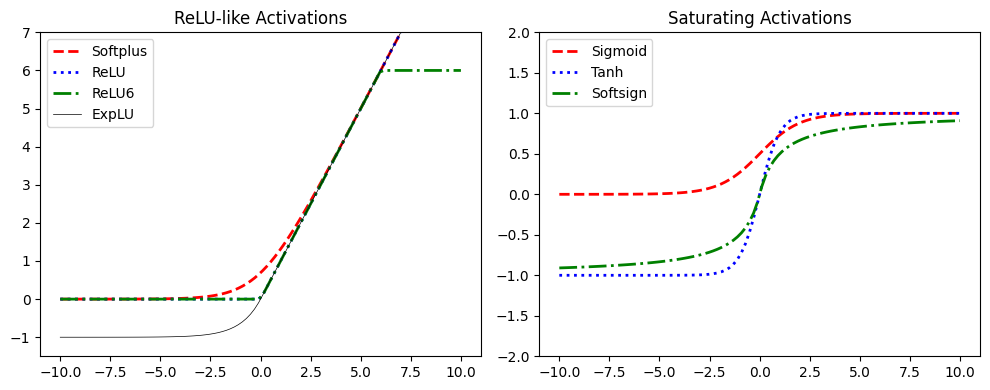

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# No sess = tf.Session() or graph reset needed in TF2

# X range
x_vals = np.linspace(start=-10., stop=10., num=100).astype(np.float32)

# 1. ReLU activation
print(tf.nn.relu([-3., 3., 10.]).numpy())
y_relu = tf.nn.relu(x_vals)

# 2. ReLU-6 activation
print(tf.nn.relu6([-3., 3., 10.]).numpy())
y_relu6 = tf.nn.relu6(x_vals)

# 3. Sigmoid activation
print(tf.nn.sigmoid([-1., 0., 1.]).numpy())
y_sigmoid = tf.nn.sigmoid(x_vals)

# 4. Hyper Tangent activation
print(tf.nn.tanh([-1., 0., 1.]).numpy())
y_tanh = tf.nn.tanh(x_vals)

# 5. Softsign activation
print(tf.nn.softsign([-1., 0., 1.]).numpy())
y_softsign = tf.nn.softsign(x_vals)

# 6. Softplus activation
print(tf.nn.softplus([-1., 0., 1.]).numpy())
y_softplus = tf.nn.softplus(x_vals)

# 7. Exponential linear activation (ELU)
print(tf.nn.elu([-1., 0., 1.]).numpy())
y_elu = tf.nn.elu(x_vals)

# --- Plotting ---
plt.figure(figsize=(10, 4))

# Chart 1: ReLU variants
plt.subplot(1, 2, 1)
plt.plot(x_vals, y_softplus, 'r--', label='Softplus', linewidth=2)
plt.plot(x_vals, y_relu, 'b:', label='ReLU', linewidth=2)
plt.plot(x_vals, y_relu6, 'g-.', label='ReLU6', linewidth=2)
plt.plot(x_vals, y_elu, 'k-', label='ExpLU', linewidth=0.5)
plt.ylim([-1.5, 7])
plt.legend(loc='upper left')
plt.title("ReLU-like Activations")

# Chart 2: Sigmoid/Tanh variants
plt.subplot(1, 2, 2)
plt.plot(x_vals, y_sigmoid, 'r--', label='Sigmoid', linewidth=2)
plt.plot(x_vals, y_tanh, 'b:', label='Tanh', linewidth=2)
plt.plot(x_vals, y_softsign, 'g-.', label='Softsign', linewidth=2)
plt.ylim([-2, 2])
plt.legend(loc='upper left')
plt.title("Saturating Activations")

plt.tight_layout()
plt.show()
